<a href="https://colab.research.google.com/github/DhanaSekhar-0-1/machine_learning/blob/main/LinearReg_ElasticNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 0. IMPORT LIBRARIES
# ===============================
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv('/content/drive/MyDrive/ Datasets_imp/house_prices_practice.csv')

print(df.head())
print(df.info())
print(df.describe())

   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0   1            7       1560           0         1658       1969         2   
1   2            4       2827           2         1319       2012         3   
2   3            8       3920           0          841       2010         1   
3   4            5       3044           0         1058       1998         0   
4   5            7        801           1         2428       2020         0   

   BedroomAbvGr  LotArea  SalePrice  
0             1     8059     177106  
1             4    13530     301044  
2             4     9010     360609  
3             4    13207     240556  
4             1     9117     193656  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-n

In [ ]:
# ===============================
# 2. DATA CLEANING
# ===============================
df = df.drop('Id', axis=1)

In [ ]:
# ===============================
# 3. FEATURES & TARGET
# ===============================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [ ]:
# ===============================
# 4. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =====================================================
# 5. MULTIPLE LINEAR REGRESSION (BASELINE)
# =====================================================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("\n=== Linear Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R²  :", r2_score(y_test, y_pred_linear))


=== Linear Regression ===
MAE : 10431.655979707499
RMSE: 12505.459264619512
R²  : 0.9724369952260797


In [ ]:
# =====================================================
# 6. FEATURE SCALING (FOR RIDGE & ELASTICNET)
# =====================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =====================================================
# 7. RIDGE REGRESSION
# =====================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("\n=== Ridge Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R²  :", r2_score(y_test, y_pred_ridge))


=== Ridge Regression ===
MAE : 10409.678222667757
RMSE: 12445.15870842261
R²  : 0.9727021685870492


In [ ]:
# =====================================================
# 8. ELASTICNET REGRESSION (NEW)
# =====================================================
# alpha = total regularization strength
# l1_ratio = mix between Lasso (1) and Ridge (0)

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

print("\n=== ElasticNet Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))
print("R²  :", r2_score(y_test, y_pred_elastic))


=== ElasticNet Regression ===
MAE : 10506.496141231257
RMSE: 12455.960978505522
R²  : 0.972654759545463


In [ ]:
# =====================================================
# 9. COEFFICIENT COMPARISON
# =====================================================
from IPython.display import display # Import display for better table rendering

coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': linear_model.coef_,
    'Ridge': ridge_model.coef_,
    'ElasticNet': elastic_model.coef_
})

print("\nCoefficient Comparison:")
display(coef_comparison) # Use display instead of print for DataFrame


Coefficient Comparison:


,Feature,Linear,Ridge,ElasticNet
0,OverallQual,11914.688135,33026.293138,31139.313766
1,GrLivArea,55.410257,56802.078228,54124.829849
2,GarageCars,19109.641614,21156.377348,20476.090494
3,TotalBsmtSF,25.199018,16594.391408,15931.279665
4,YearBuilt,746.370978,15815.971047,15382.819747
5,FullBath,11040.343046,12513.717799,12153.531362
6,BedroomAbvGr,4812.061994,6879.467253,6008.688000
7,LotArea,-0.159522,-612.623174,-706.360132


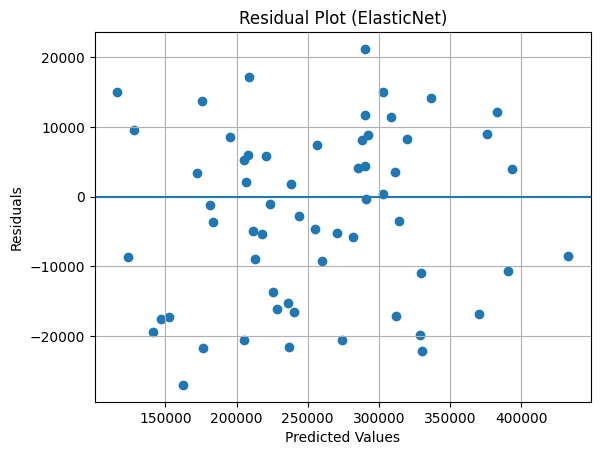

In [ ]:
# =====================================================
# 10. RESIDUAL PLOT (ELASTICNET)
# =====================================================
elastic_residuals = y_test - y_pred_elastic

plt.figure()
plt.scatter(y_pred_elastic, elastic_residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (ElasticNet)")
plt.grid(True)
plt.show()

In [ ]:
# =====================================================
# 11. NEW HOUSE PREDICTION (ELASTICNET)
# =====================================================
new_house = pd.DataFrame({
    'OverallQual': [7],
    'GrLivArea': [2500],
    'GarageCars': [2],
    'TotalBsmtSF': [1500],
    'YearBuilt': [2015],
    'FullBath': [2],
    'BedroomAbvGr': [3],
    'LotArea': [9000]
})

new_house = new_house[X.columns]
#Transformation required for Ridge and ElasticNet
new_house_scaled = scaler.transform(new_house)
elastic_price = elastic_model.predict(new_house_scaled)

print("\nPredicted House Price (ElasticNet):", elastic_price[0])

#Comparisions Linear Regression and Ridge Regression
ridge_price = ridge_model.predict(new_house_scaled)
print("Predicted House Price (Ridge Regression):", ridge_price[0])
linear_price = linear_model.predict(new_house)
print("Predicted House Price (Multiple Linear Regression):", linear_price[0])


Predicted House Price (ElasticNet): 321020.0985687035
Predicted House Price (Ridge Regression): 323872.92899681046
Predicted House Price (Multiple Linear Regression): 324144.3962463846


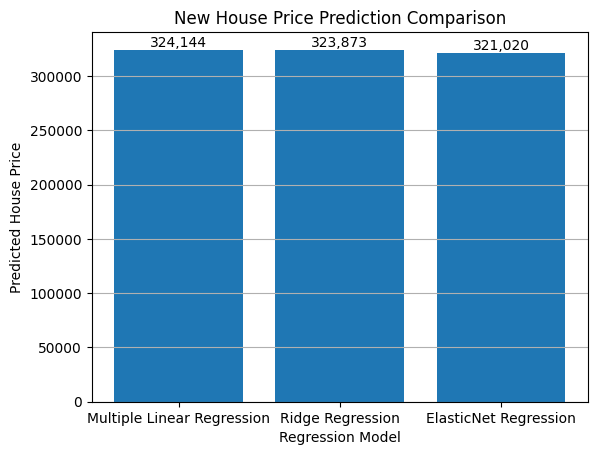

In [ ]:
# ===============================
# COLLECT PREDICTIONS
# ===============================
models = [
    "Multiple Linear Regression",
    "Ridge Regression",
    "ElasticNet Regression"
]

prices = [
    linear_price[0],
    ridge_price[0],
    elastic_price[0]
]

# ===============================
# BAR CHART COMPARISON
# ===============================
plt.figure()
plt.bar(models, prices)
plt.xlabel("Regression Model")
plt.ylabel("Predicted House Price")
plt.title("New House Price Prediction Comparison")
plt.grid(axis='y')

# Add value labels on bars
for i, value in enumerate(prices):
    plt.text(i, value, f"{value:,.0f}", ha='center', va='bottom')

plt.show()


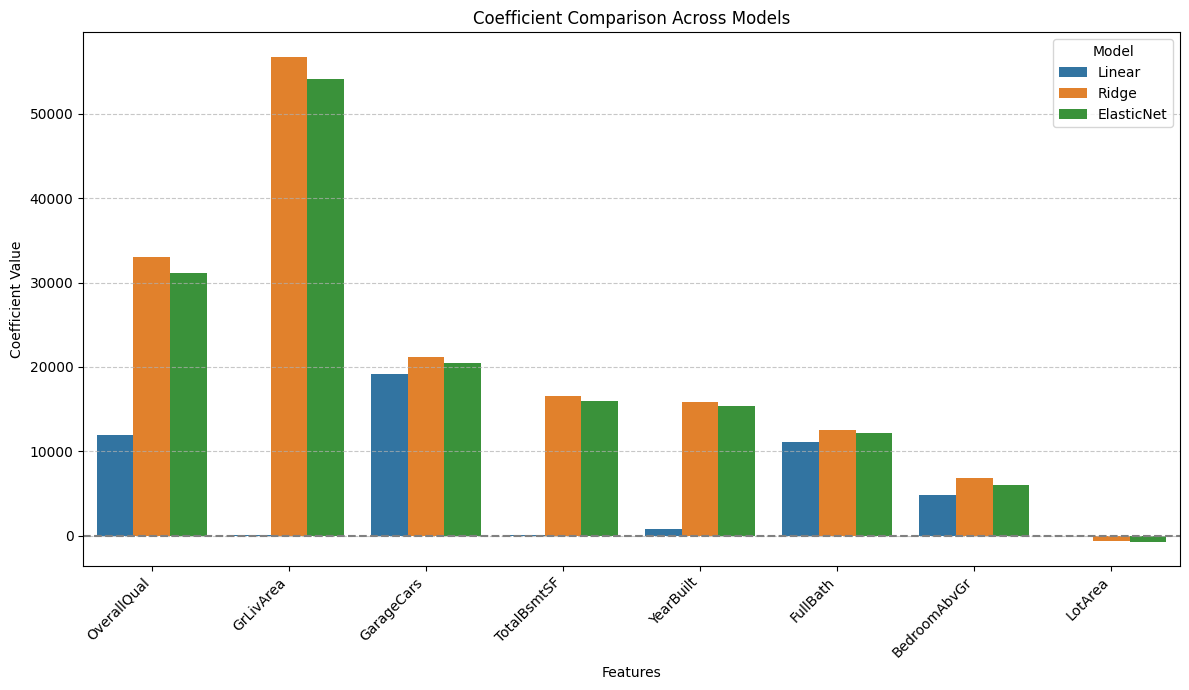

In [ ]:
# =====================================================
# 12. COEFFICIENT COMPARISON BAR CHART
# =====================================================
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
coef_melted = coef_comparison.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coef_melted)
plt.title('Coefficient Comparison Across Models')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='grey', linestyle='--') # Add a zero line for reference
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

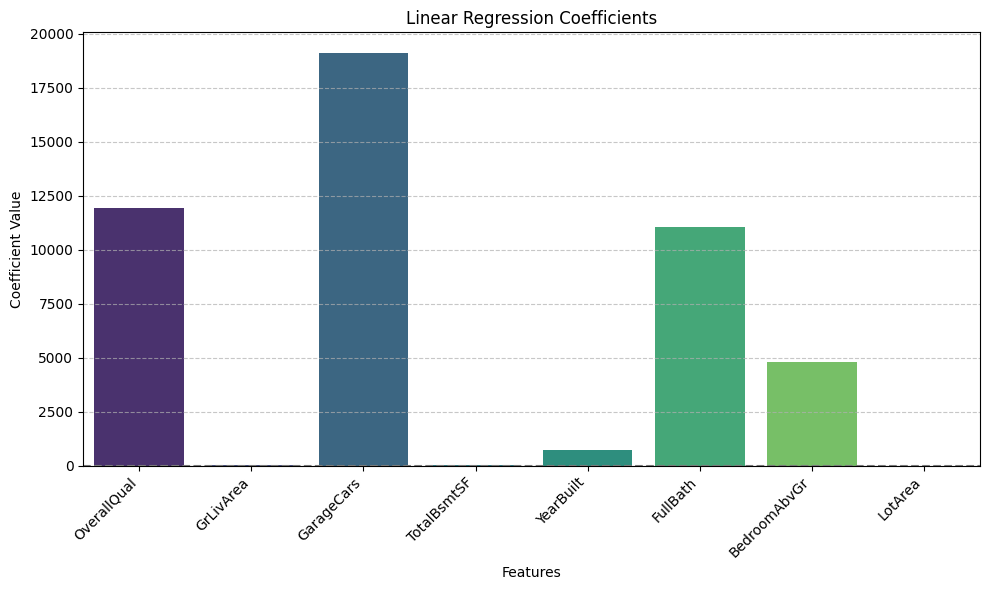

In [ ]:
# =====================================================
# 13. COEFFICIENT BAR CHART (LINEAR REGRESSION)
# =====================================================
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Linear', data=coef_comparison, palette='viridis', hue='Feature', legend=False)
plt.title('Linear Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='grey', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

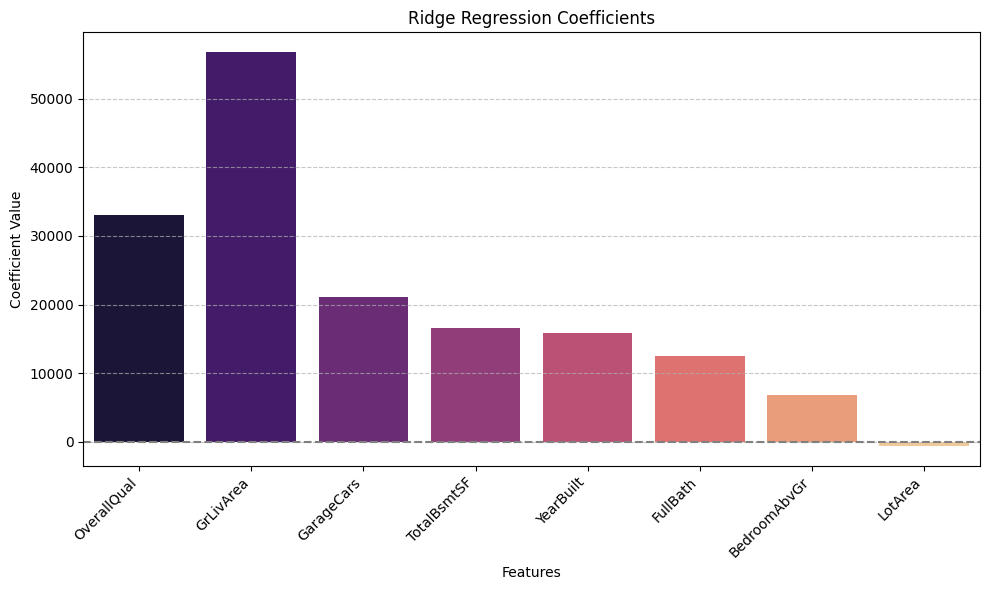

In [ ]:
# =====================================================
# 14. COEFFICIENT BAR CHART (RIDGE REGRESSION)
# =====================================================
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Ridge', data=coef_comparison, palette='magma', hue='Feature', legend=False)
plt.title('Ridge Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='grey', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

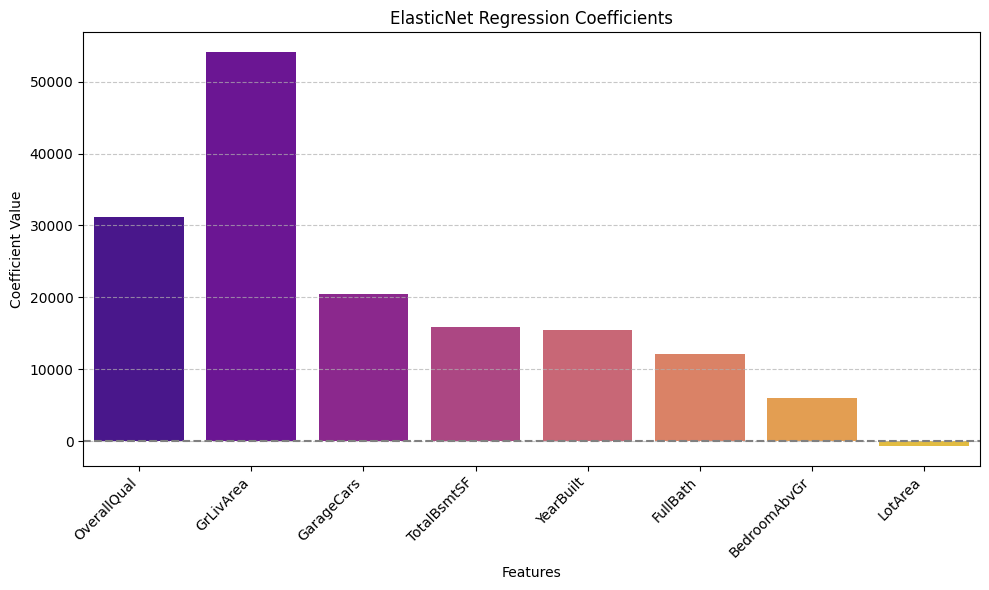

In [ ]:
# =====================================================
# 15. COEFFICIENT BAR CHART (ELASTICNET REGRESSION)
# =====================================================
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='ElasticNet', data=coef_comparison, palette='plasma', hue='Feature', legend=False)
plt.title('ElasticNet Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='grey', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()